## Preamble

In [2]:
import os
import numpy as np
#from scipy import signal
import matplotlib.pyplot as plt

In [24]:
ε_r=12; μ_r=1; σ=0.006

v = 299/np.sqrt(ε_r*μ_r)
print('v =',v) #86 m/μs

fpeak = 400 #MHz

λmin = v/fpeak/2
print('λmin =',λmin) #0.108 m

h=0.02 #m

nz=201; nx=201
nzsnap=nz+48
nxsnap=nx+48
nsnap=51
print(f'length = {(nz-1)*h} m')

dt_CFL = 0.6*h/v
print('dt_CFL =',dt_CFL) #μs
dt = 0.0001 #μs

nt = 700
t=np.arange(0,nt*dt,dt)

v = 86.31386524384905
λmin = 0.10789233155481132
length = 4.0 m
dt_CFL = 0.000139027489570746


In [30]:
def read(filename,n=(nx,nz)):
    return np.fromfile(filename,dtype='float32').reshape(n).T

nr=1
def read_su(filename,n=(nr,nt)):
    data=read(filename,n=(n[0],int(60+n[1])))
    return data[60:,:]

def read_snap(filename,n=(nsnap,nxsnap,nzsnap),i=17):
    tmp=np.fromfile(filename,dtype='float32').reshape(n).T
    return tmp[24:24+nz,24:24+nx,i]

def imshow(data,perc=None,clip=None,clipmin=None,extent=None,cmap='viridis',title=None,grid=True):
    
    if perc==None:
        clipp=[np.amin(data),np.amax(data)]
    else:
        tmp=np.percentile(np.abs(data),q=perc)
        clipp=[-tmp,tmp]
    
    if clip!=None: clipp=clip
    
    if clipmin!=None: clipp[0]=clipmin
    
    plt.imshow(data,vmin=clipp[0],vmax=clipp[1],extent=extent,cmap=cmap,aspect='auto')
    plt.colorbar(location='right')
    plt.grid(visible=grid, axis='both', which='both', color='w', linestyle='--',linewidth=0.5)
    #plt.xlabel(labels[0]); plt.ylabel(labels[1])
    if title!=None: plt.title(title)

def run(app='../../exe/FWI',setup='setup',np=1,nthreads=8,out=None):
    '''
    run(app,setup,np=1,nthreads=8)
    run in a bash env
    ----------------------------
    app      : application/executable to run
    setup    : setup file
    np       : number of MPI processors (default=1)
    nthreads : number of OpenMP threads (default=8)
    
    Caveat: np*nthreads should not exceed total number of CPU cores
    otherwise the running will be very slow
    '''
    
    !echo 'ulimit -s unlimited' > run.sh
    str=f"export OMP_NUM_THREADS={nthreads}"
    !echo $str >> run.sh
    str=f"{app} {setup}"
    !echo $str >> run.sh
    !chmod +x run.sh
    if out==None:
        !./run.sh
    else:
        !./run.sh > {out}

In [12]:
eps_r = ε_r*np.ones((nz,nx)); eps_r[nz//2:,:]=ε_r/2
mu_r  = μ_r*np.ones((nz,nx));  mu_r[nz//2:,:]=1.2
sgma  = σ  *np.ones((nz,nx));  sgma[nz//2:,:]=σ/2

model=np.concatenate((eps_r,mu_r,sgma),axis=1)
model.T.astype('float32').tofile('model')

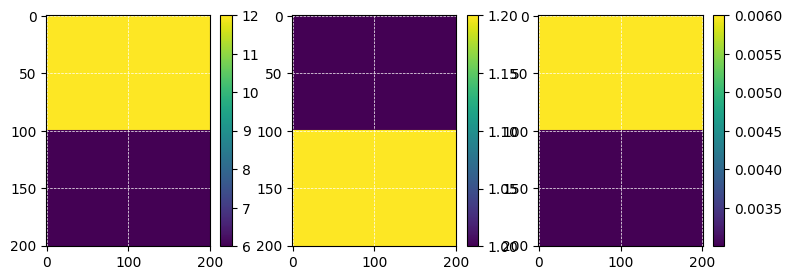

In [15]:
model=read('model',(3*nx,nz))

plt.figure(figsize=(9,3))
plt.subplot(1,3,1); imshow(model[:,:nx])
plt.subplot(1,3,2); imshow(model[:,nx:2*nx])
plt.subplot(1,3,3); imshow(model[:,2*nx:])

In [4]:
#!cd ../../; sed -i 's/WaveEq=DAS/WaveEq=SH/' modules.inc
#!make
!make cleanall; make
#!make

#System
(cd ../../Modules/System; make clean)
make[1]: Entering directory '/home/joey/Codes/GitHub/SeisJIMU/Modules/System'
rm m_either.o m_string.o m_mpienv.o m_message.o m_arrayop.o m_setup.o m_sysio.o m_checkpoint.o m_suformat.o m_System.o

rm ../../mod/m_either.mod ../../mod/m_string.mod ../../mod/m_mpienv.mod ../../mod/m_message.mod ../../mod/m_arrayop.mod ../../mod/m_setup.mod ../../mod/m_sysio.mod ../../mod/m_checkpoint.mod ../../mod/m_suformat.mod ../../mod/m_System.mod ../../mod/m_system.mod
rm: cannot remove '../../mod/m_System.mod': No such file or directory
make[1]: [Makefile:25: clean] Error 1 (ignored)

make[1]: Leaving directory '/home/joey/Codes/GitHub/SeisJIMU/Modules/System'
#Etc
(cd ../../Modules/Etc; make clean)
make[1]: Entering directory '/home/joey/Codes/GitHub/SeisJIMU/Modules/Etc'
rm sgtsv.o m_math.o singleton.o

rm ../../mod/m_math.mod ../../mod/singleton.mod

make[1]: Leaving directory '/home/joey/Codes/GitHub/SeisJIMU/Modules/Etc'
#Signal
(cd ../../Modules/S

In [25]:
%%writefile setup_default

MODEL_SIZE              '201   201   1'
MODEL_SPACING           '0.02 0.02  1'
MODEL_ORIGIN            '0     0     0'
FILE_MODEL              'model'
MODEL_ATTRIBUTES        'eps_r mu_r sgma'
NAIRL                    0

ACQUI_GEOMETRY          spread
FS                      '1  1  0'
FR                      '1  3  0'
DR                      '0  0  0'
NR                       1

IF_HICKS                 F

SCOMP                    Ey
RCOMP                    Ey

NT                       700
DT                       0.0001
WAVELET_TYPE             ricker
FPEAK                    400

SNAPSHOT                'Hx Hz Ey'

IF_USE_CHECKPOINT        F

Overwriting setup_default


## Test FWD

In [31]:
!cp setup_default setup
!echo "DIR_OUT   res_fwd" >> setup
run(app='../../exe/fwd_TE_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/joey/Codes/GitHub/SeisJIMU/Demo/03_AdjointTest
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 joey joey 2176512 Jun 19 22:44 ../../exe/fwd_TE_FDSG_O4_
 Git Commit: cfd890f
 Git Branch: GPR
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 06/20/2026
System time: 20:28:39
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : res_fwd
 Output directory:res_fwd/
 Invoked field & propagator modules info : 
Time-domain isotropic Transverse Electric (TE) wave propagation
1st-order H-E formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤ 0.606(for 2D) or 0.494(3D)

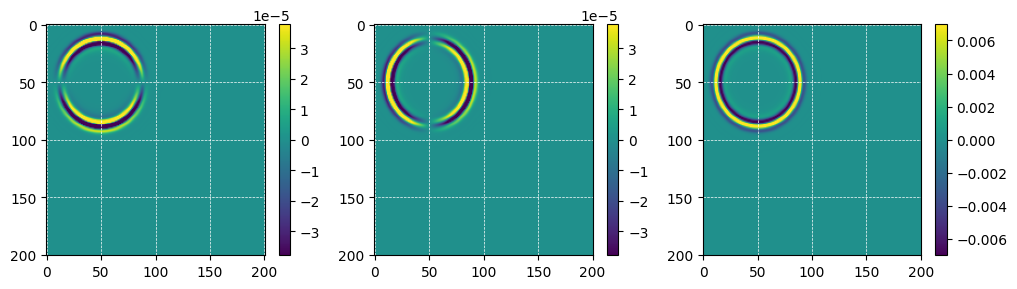

In [32]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('res_fwd/snap_fld_u%Hx',i=8),perc=98)
plt.subplot(1,3,2); imshow(read_snap('res_fwd/snap_fld_u%Hz',i=8),perc=98)
plt.subplot(1,3,3); imshow(read_snap('res_fwd/snap_fld_u%Ey',i=8),perc=98)

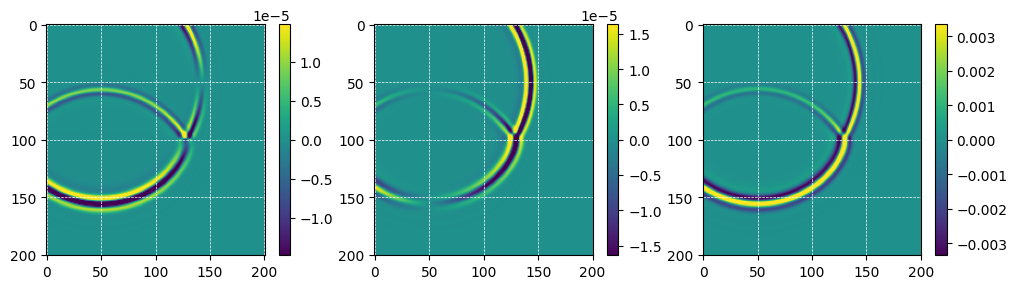

In [33]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('res_fwd/snap_fld_u%Hx'),perc=98)
plt.subplot(1,3,2); imshow(read_snap('res_fwd/snap_fld_u%Hz'),perc=98)
plt.subplot(1,3,3); imshow(read_snap('res_fwd/snap_fld_u%Ey'),perc=98)

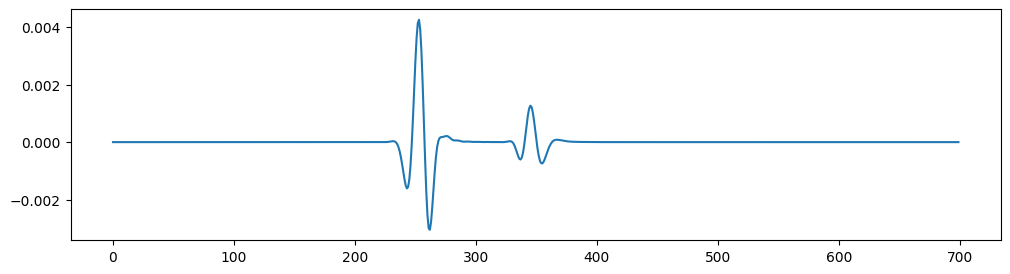

In [34]:
plt.figure(figsize=(12,3))
plt.plot(read_su('res_fwd/Ru_Shot0001.su'))

## Adjoint Test

### Ey-Ey

In [41]:
!cp setup_default setup
#!echo "IF_USE_RANDOM F" >> setup
run(app='../../exe/adjointtest_TE_FDSG_O4',out='out')

!tail -10 out

 LHS = <  v|Lu> =    2.3058285738011540E-006
 RHS = <Lᴴv| u> =    2.3058191516945163E-006
 relative difference =    4.0862129755766087E-004  %
   SeisJIMU has finished the job   
 System date: 06/20/2026
System time: 21:01:19
System timezone: +03:00
                        
